### Preparation

In [1]:
# use Jupyter magic's fonction autoreload : reload modules each time the code is executed
%load_ext autoreload
%autoreload 2
%matplotlib widget
# enable the Jupyter plugin to monitor execution times
# !jupyter nbextension enable execute_time/ExecuteTime


In [12]:
from HR_SpARTA.reduction import load_transit, DataSet
from HR_SpARTA.transits_parameters import *
from pprint import pprint
from HR_SpARTA.AtmoModel import AtmoModel
import pickle


11:54:25.565278 : AtmoModel.py has been loaded


In [13]:
# load any data_set for the targeted instrument & planet, we just need to know the planet/stellar parameters & wavelength range
data_set = load_transit(WASP76_2020)


Loading files with format 't.fits' in './data/WASP-76/2020-10-31/' :
27 out of 54 files selected !

The following hdu will be extracted with the following roles. Please make sure this is what you want :
Selected HDU 'FluxAB' at index 1 as 'data'.
Selected HDU 'WaveAB' at index 2 as 'wavelengths'.
Selected HDU 'BlazeAB' at index 3 as 'blaze'.
Selected HDU 'Recon' at index 4 as 'tellurics'.
Selected HDU 'OHLine' at index 5 as 'OHLine'.

Building data cube of shape : (27, 49, 4088)
Filling the data cube with selected files...

Building the off-transit spectra masked :

27 / 27
Found 10 off-transit spectra among 27 spectra

Find off transit spectra done !

This step has been saved with ID : 'find_off_transit'
------------------------------
Compute Kepler orbit done
Compute transit window weight orbit done

27 files with 't.fits' have been succesfully loaded from './data/WASP-76/2020-10-31/'
Data, wavelengths, blaze and corresponding headers have all been loaded from these files in data cub

In [14]:
# Setup the grid
atmo_grid = {
    'Tiso' : np.linspace(500,2000,4),
    'log_MMR': {
        'H2O': np.linspace(-6,-2,5),
        'CO' : np.linspace(-6,-2,5)
        }
    }

pprint(atmo_grid)


{'Tiso': array([ 500., 1000., 1500., 2000.]),
 'log_MMR': {'CO': array([-6., -5., -4., -3., -2.]),
             'H2O': array([-6., -5., -4., -3., -2.])}}


In [15]:
# Load model
Model = AtmoModel(data_set,[key for key in atmo_grid['log_MMR']], lbl_sampling=4)


Loading Radtrans opacities...
 Loading line opacities of species 'H2O' from file '/home/amasson/data/petitRADTRANS/Lines/input_data/opacities/lines/line_by_line/H2O/1H2-16O/1H2-16O__HITRAN.R1e6_0.3-28mu.xsec.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CO' from file '/home/amasson/data/petitRADTRANS/Lines/input_data/opacities/lines/line_by_line/CO/12C-16O/12C-16O__HITEMP.R1e6_0.3-28mu.xsec.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2-H2 from file '/home/amasson/data/petitRADTRANS/Lines/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2-He from file '/home/amasson/data/petitRADTRANS/Lines/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA o

CPU times: user 4.54 s, sys: 2.55 s, total: 7.09 s
Wall time: 4.67 s


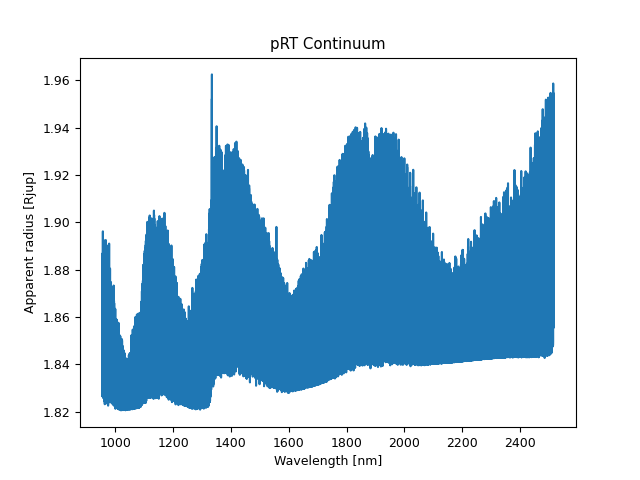

In [16]:
# test single computation
%time wave, radius = Model.compute_pRT({'Tiso':1200,'log_MMR':{'H2O':-3,'CO':-4}},plot=True)


In [17]:
# Compute grid : set the file output & the Nb of threads to use for parallel computing!
grid_file = './wasp76_h2o_co' # output file

%time Model.build_interpolation_grid(atmo_grid, Nb_threads=10, output_file=grid_file, skip_memory_check=False)


Computing a dummy model to get wavelength & model size...


line species 'CO' initialised to 2.2250738585072014e-308 ; to remove this warning set use_equilibrium_chemistry to True or add 'CO' and the desired mass mixing ratio to imposed_mass_fractions


Single model computed in 4.74 s
Found 4 Tiso values
Found 5 log_MMR_H2O values
Found 5 log_MMR_CO values
Grid size: 4x5x5x241949, 100 parameters in total
Expected memory usage: 0.18 Gb.

CONFIRM PROCEED OR CANCEL IN INPUT BOX!
Computing grid...

101 %
Full grid computed in 333.92 s
Building and saving interpoler, this can take some time...
All done !
CPU times: user 21min 37s, sys: 9min 15s, total: 30min 52s
Wall time: 5min 47s


In [18]:
# Load grid and test it
with open(f'{grid_file}.pkl', 'rb') as f:
    interpoler_grid = pickle.load(f)

with open(f'{grid_file}_readme.txt', 'r') as f:
    print(f.readlines())

interp_wave = np.loadtxt(f'{grid_file}_wave.dat')
interp_wave.shape


12:01:22.681683 : AtmoModel.py has been loaded
['Nb dimension: 3\n', '                Grid shape: (4, 5, 5, 241949)\n', "                Dimensions: dict_keys(['Tiso', 'log_MMR_H2O', 'log_MMR_CO'])\n", "                {'Tiso': array([ 500., 1000., 1500., 2000.]), 'log_MMR_H2O': array([-6., -5., -4., -3., -2.]), 'log_MMR_CO': array([-6., -5., -4., -3., -2.])}"]


(241949,)

In [21]:
# Compute new model & compare direct/interpolated computations
params = {
    'Tiso': 1200,
    'log_MMR':{
        'H2O': -2.5,
        'CO': -3.4
    },
}

%time interpolated_model = interpoler_grid((params['Tiso'],params['log_MMR']['H2O'],params['log_MMR']['CO']))

%time wave, direct_model = Model.compute_pRT(params)




CPU times: user 9.89 ms, sys: 960 µs, total: 10.9 ms
Wall time: 9.73 ms
CPU times: user 4.75 s, sys: 2.4 s, total: 7.15 s
Wall time: 4.77 s


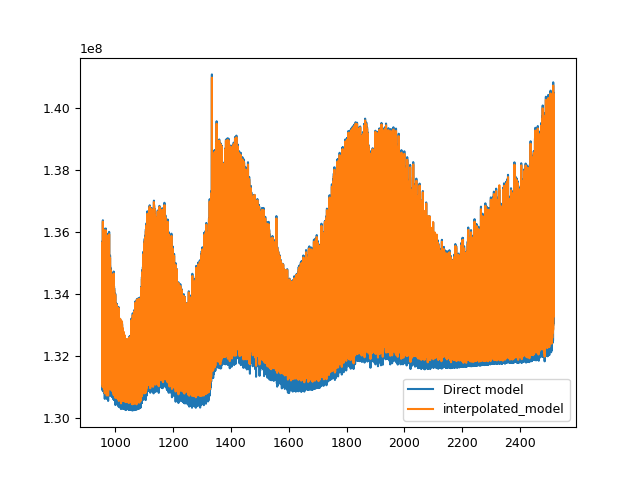

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(wave,direct_model,label='Direct model')
plt.plot(interp_wave,interpolated_model,label='interpolated_model')
plt.legend()


Loading interpoler: ./wasp76_h2o_co.pkl 
Here's the associated readme: make sure to set the atmospheric parameter in the same order and within the pre-computed interpolation grid!
['Nb dimension: 3\n', '                Grid shape: (4, 5, 5, 241949)\n', "                Dimensions: dict_keys(['Tiso', 'log_MMR_H2O', 'log_MMR_CO'])\n", "                {'Tiso': array([ 500., 1000., 1500., 2000.]), 'log_MMR_H2O': array([-6., -5., -4., -3., -2.]), 'log_MMR_CO': array([-6., -5., -4., -3., -2.])}"]
./wasp76_h2o_co.pkl succesfully loaded, synthetic will be interpolated instead of direct computation
CPU times: user 6.84 ms, sys: 0 ns, total: 6.84 ms
Wall time: 6.85 ms
CPU times: user 4.66 s, sys: 2.62 s, total: 7.28 s
Wall time: 4.86 s


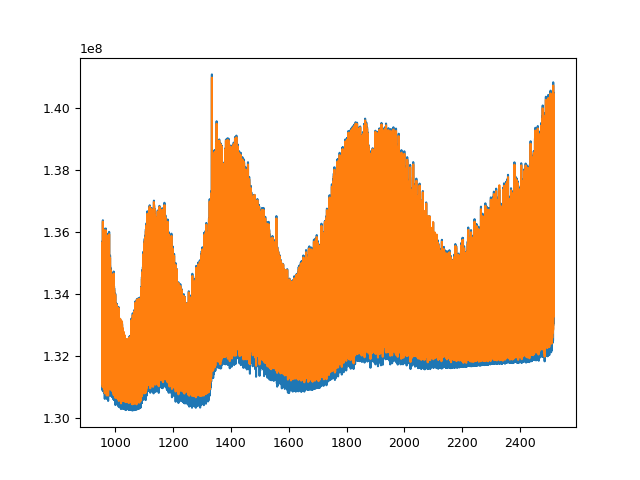

In [25]:
# Now try with the built-in method in Model
Model2 = AtmoModel(data_set,interpoler_path=grid_file+".pkl")

%time wave_interp, model_interp = Model2.interpolate_pRT(params)
%time wave, model = Model.compute_pRT(params)

plt.figure()
plt.plot(wave,model)
plt.plot(wave_interp, model_interp)
